# Exploratory Statistics on 256-Dimensional Latent Vectors
Extract and analyze latent vectors from the weighted encoder

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm.auto import tqdm
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import importlib
import models.autoencoder.bottleneck_models
importlib.reload(models.autoencoder.bottleneck_models)

from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.bottleneck_models import (
    BottleneckEncoder,
    ComplexBottleneckDeconvDecoder,
    BottleneckAE,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Configuration

In [2]:
root_dir = Path(".")
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 1
latent_dim = 256
weighted_output_dir = "output/Experiments/BottleneckDeconvWeightedTraining"
latent_output_dir = "output/Experiments/LatentVectorAnalysis"

os.makedirs(latent_output_dir, exist_ok=True)
print(f"Output directory: {latent_output_dir}")

Output directory: output/Experiments/LatentVectorAnalysis


## Load Data

In [3]:
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files")

print("Generating dataframe...")
df = generate_dataframe(included_files)

print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path,
    num_workers=0
)

print(f"Validation subjects: {len(val_loader.dataset)}")
print(f"Train subjects: {len(train_loader.dataset)}")

Found 2976 valid files
Generating dataframe...
Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Validation subjects: 596
Train subjects: 2380


## Build Encoder

In [4]:
def build_encoder(latent_dim=256):
    encoder = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1))
    return encoder.to(device)

def build_full_model(latent_dim=256):
    target_shape = (64, 128, 128)
    model = BottleneckAE(
        BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1)),
        ComplexBottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
    )
    return model.to(device)

## Load Weighted Model and Extract Encoder

In [5]:
weighted_model_name = f"deconv_weighted_lat{latent_dim}"
weighted_checkpoint_path = os.path.join(weighted_output_dir, weighted_model_name, f"{weighted_model_name}_best.pth")

print(f"Loading weighted model...")
full_model = build_full_model(latent_dim=latent_dim)
full_model.load_state_dict(torch.load(weighted_checkpoint_path, map_location=device))
full_model = full_model.eval()

# Extract encoder
encoder = full_model.encoder
print(f"✓ Loaded weighted encoder")

Loading weighted model...
✓ Loaded weighted encoder


## Extract Latent Vectors - Validation Set

In [6]:
val_latent_vectors = []
val_labels = []

print(f"Extracting latent vectors from {len(val_loader)} validation subjects...")
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(val_loader, desc="Validation")):
        inp = batch['volume'].to(device)
        label = batch['label'][0]
        
        # Get latent vector
        latent = encoder(inp)
        latent_vector = latent.squeeze().cpu().numpy()
        
        val_latent_vectors.append(latent_vector)
        val_labels.append(label)

val_latent_array = np.array(val_latent_vectors)
print(f"Validation latent vectors shape: {val_latent_array.shape}")
print(f"Validation labels: {pd.Series(val_labels).value_counts().to_dict()}")

Extracting latent vectors from 596 validation subjects...


Validation:   0%|          | 0/596 [00:00<?, ?it/s]

Validation latent vectors shape: (596, 256)
Validation labels: {'PD': 510, 'Control': 59, 'SWEDD': 27}


## Extract Latent Vectors - Test Set

In [7]:
test_latent_vectors = []
test_labels = []

print(f"Extracting latent vectors from {len(train_loader)} test subjects...")
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(train_loader, desc="Test")):
        inp = batch['volume'].to(device)
        label = batch['label'][0]
        
        # Get latent vector
        latent = encoder(inp)
        latent_vector = latent.squeeze().cpu().numpy()
        
        test_latent_vectors.append(latent_vector)
        test_labels.append(label)

test_latent_array = np.array(test_latent_vectors)
print(f"Test latent vectors shape: {test_latent_array.shape}")
print(f"Test labels: {pd.Series(test_labels).value_counts().to_dict()}")

Extracting latent vectors from 2380 test subjects...


Test:   0%|          | 0/2380 [00:00<?, ?it/s]

Test latent vectors shape: (2380, 256)
Test labels: {'PD': 2035, 'Control': 235, 'SWEDD': 110}


## Save Latent Vectors

In [8]:
# Save validation latent vectors
val_latent_df = pd.DataFrame(val_latent_array, columns=[f'latent_{i}' for i in range(latent_dim)])
val_latent_df['Label'] = val_labels
val_latent_df['Dataset'] = 'Validation'
val_latent_df.to_csv(os.path.join(latent_output_dir, 'validation_latent_vectors.csv'), index=False)
print(f"Saved validation latent vectors to {os.path.join(latent_output_dir, 'validation_latent_vectors.csv')}")

# Save test latent vectors
test_latent_df = pd.DataFrame(test_latent_array, columns=[f'latent_{i}' for i in range(latent_dim)])
test_latent_df['Label'] = test_labels
test_latent_df['Dataset'] = 'Test'
test_latent_df.to_csv(os.path.join(latent_output_dir, 'test_latent_vectors.csv'), index=False)
print(f"Saved test latent vectors to {os.path.join(latent_output_dir, 'test_latent_vectors.csv')}")

Saved validation latent vectors to output/Experiments/LatentVectorAnalysis/validation_latent_vectors.csv
Saved test latent vectors to output/Experiments/LatentVectorAnalysis/test_latent_vectors.csv


## Descriptive Statistics

In [9]:
print("\n" + "="*80)
print("VALIDATION SET - LATENT VECTOR STATISTICS")
print("="*80)

for label in sorted(set(val_labels)):
    mask = np.array(val_labels) == label
    label_vectors = val_latent_array[mask]
    
    print(f"\n{label} (n={mask.sum()}):")
    print(f"  Mean: {label_vectors.mean(axis=0).mean():.6f}")
    print(f"  Std:  {label_vectors.std(axis=0).mean():.6f}")
    print(f"  Min:  {label_vectors.min():.6f}")
    print(f"  Max:  {label_vectors.max():.6f}")

print(f"\nOverall:")
print(f"  Mean: {val_latent_array.mean():.6f}")
print(f"  Std:  {val_latent_array.std():.6f}")
print(f"  Min:  {val_latent_array.min():.6f}")
print(f"  Max:  {val_latent_array.max():.6f}")


VALIDATION SET - LATENT VECTOR STATISTICS

Control (n=59):
  Mean: -0.299855
  Std:  2.647061
  Min:  -42.876793
  Max:  46.976215

PD (n=510):
  Mean: -0.225022
  Std:  2.534842
  Min:  -66.064919
  Max:  64.978561

SWEDD (n=27):
  Mean: -0.263922
  Std:  2.557729
  Min:  -40.748959
  Max:  45.885357

Overall:
  Mean: -0.234192
  Std:  5.748137
  Min:  -66.064919
  Max:  64.978561


In [10]:
print("\n" + "="*80)
print("TEST SET - LATENT VECTOR STATISTICS")
print("="*80)

for label in sorted(set(test_labels)):
    mask = np.array(test_labels) == label
    label_vectors = test_latent_array[mask]
    
    print(f"\n{label} (n={mask.sum()}):")
    print(f"  Mean: {label_vectors.mean(axis=0).mean():.6f}")
    print(f"  Std:  {label_vectors.std(axis=0).mean():.6f}")
    print(f"  Min:  {label_vectors.min():.6f}")
    print(f"  Max:  {label_vectors.max():.6f}")

print(f"\nOverall:")
print(f"  Mean: {test_latent_array.mean():.6f}")
print(f"  Std:  {test_latent_array.std():.6f}")
print(f"  Min:  {test_latent_array.min():.6f}")
print(f"  Max:  {test_latent_array.max():.6f}")


TEST SET - LATENT VECTOR STATISTICS

Control (n=235):
  Mean: -0.273211
  Std:  2.994143
  Min:  -46.266045
  Max:  52.061436

PD (n=2035):
  Mean: -0.212656
  Std:  2.956307
  Min:  -82.772820
  Max:  90.616730

SWEDD (n=110):
  Mean: -0.291717
  Std:  2.947185
  Min:  -42.063484
  Max:  43.158310

Overall:
  Mean: -0.222289
  Std:  5.931202
  Min:  -82.772820
  Max:  90.616730


## Per-Dimension Statistics

In [11]:
# Compute per-dimension statistics
val_per_dim_stats = pd.DataFrame({
    'Dimension': range(latent_dim),
    'Mean': val_latent_array.mean(axis=0),
    'Std': val_latent_array.std(axis=0),
    'Min': val_latent_array.min(axis=0),
    'Max': val_latent_array.max(axis=0),
    'Range': val_latent_array.max(axis=0) - val_latent_array.min(axis=0),
})

val_per_dim_stats.to_csv(os.path.join(latent_output_dir, 'validation_per_dimension_stats.csv'), index=False)
print(f"Validation per-dimension statistics:")
print(val_per_dim_stats.describe())

test_per_dim_stats = pd.DataFrame({
    'Dimension': range(latent_dim),
    'Mean': test_latent_array.mean(axis=0),
    'Std': test_latent_array.std(axis=0),
    'Min': test_latent_array.min(axis=0),
    'Max': test_latent_array.max(axis=0),
    'Range': test_latent_array.max(axis=0) - test_latent_array.min(axis=0),
})

test_per_dim_stats.to_csv(os.path.join(latent_output_dir, 'test_per_dimension_stats.csv'), index=False)
print(f"\nTest per-dimension statistics:")
print(test_per_dim_stats.describe())

Validation per-dimension statistics:
        Dimension        Mean         Std         Min         Max       Range
count  256.000000  256.000000  256.000000  256.000000  256.000000  256.000000
mean   127.500000   -0.234192    2.608704   -9.701656    9.479877   19.181534
std     74.045031    5.080313    0.727358    8.319012    7.936400    7.791680
min      0.000000  -22.010342    1.867907  -66.064919   -8.209923   11.444336
25%     63.750000   -1.095186    2.203859  -10.157998    6.553171   14.845117
50%    127.500000   -0.166263    2.396567   -7.989581    8.116845   16.861443
75%    191.250000    0.906451    2.771702   -6.821043   10.206409   20.196758
max    255.000000   22.399923    6.595363   11.249660   64.978561   59.910069

Test per-dimension statistics:
        Dimension        Mean         Std         Min         Max       Range
count  256.000000  256.000000  256.000000  256.000000  256.000000  256.000000
mean   127.500000   -0.222289    3.007465  -14.654583   13.947428   28.60

## Visualization - Distribution of Latent Dimensions

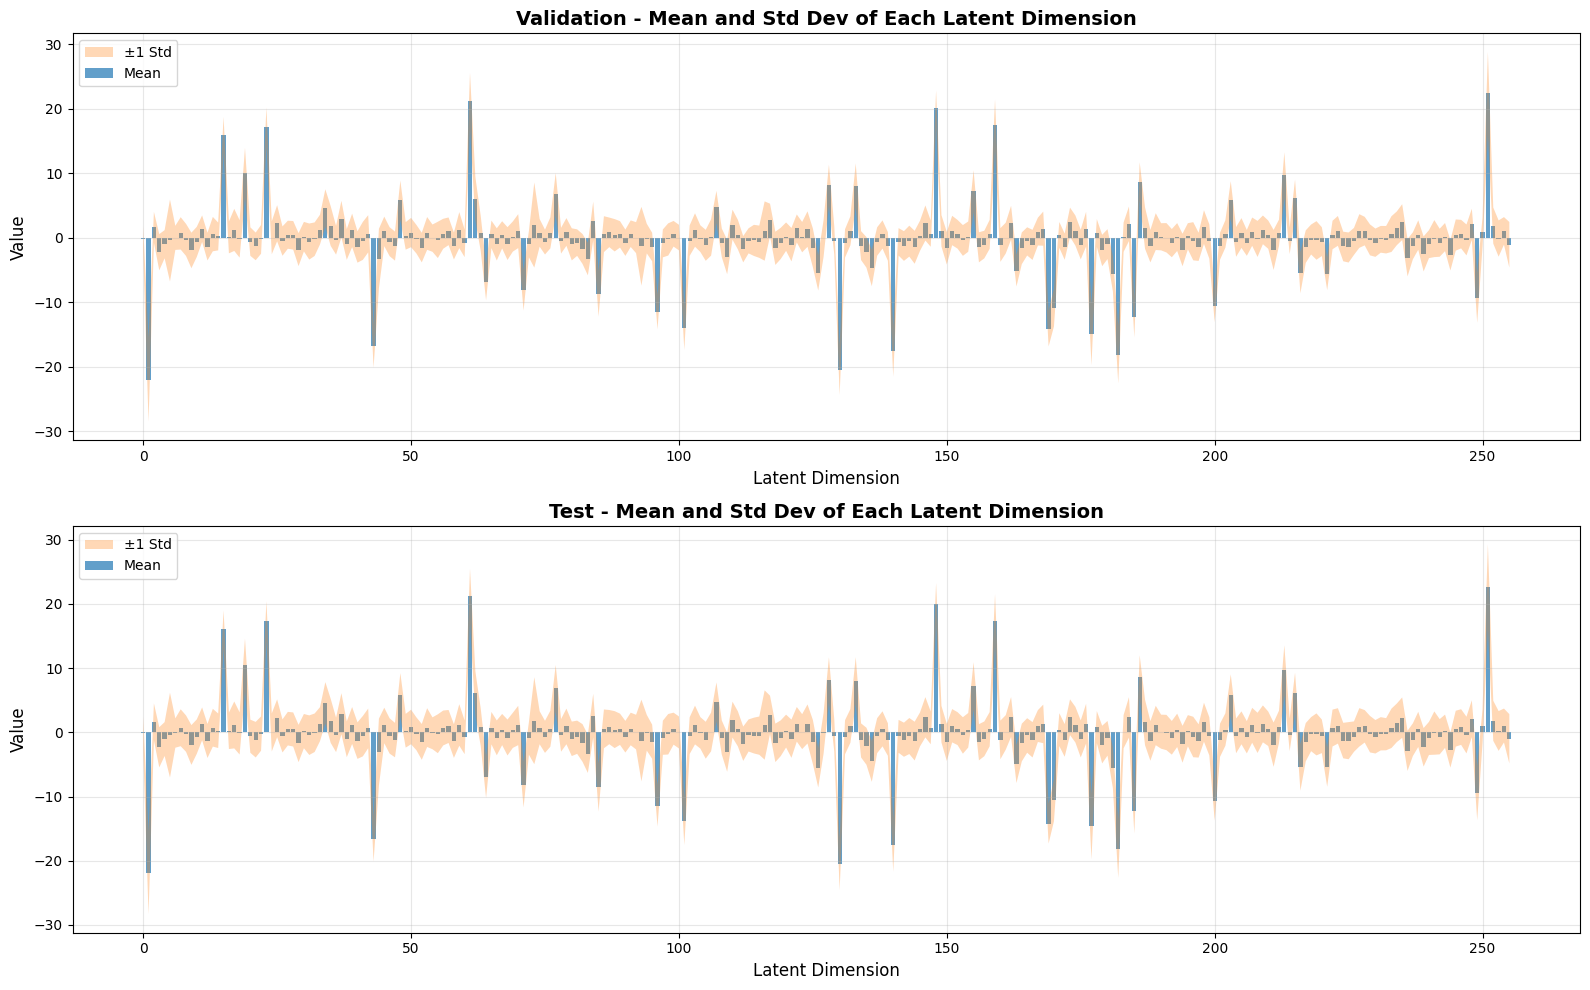

Saved to output/Experiments/LatentVectorAnalysis/latent_dimensions_stats.png


In [12]:
# Plot mean and std of each dimension
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Validation
axes[0].bar(val_per_dim_stats['Dimension'], val_per_dim_stats['Mean'], alpha=0.7, label='Mean')
axes[0].fill_between(val_per_dim_stats['Dimension'], 
                       val_per_dim_stats['Mean'] - val_per_dim_stats['Std'],
                       val_per_dim_stats['Mean'] + val_per_dim_stats['Std'],
                       alpha=0.3, label='±1 Std')
axes[0].set_title('Validation - Mean and Std Dev of Each Latent Dimension', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Latent Dimension', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].bar(test_per_dim_stats['Dimension'], test_per_dim_stats['Mean'], alpha=0.7, label='Mean')
axes[1].fill_between(test_per_dim_stats['Dimension'], 
                       test_per_dim_stats['Mean'] - test_per_dim_stats['Std'],
                       test_per_dim_stats['Mean'] + test_per_dim_stats['Std'],
                       alpha=0.3, label='±1 Std')
axes[1].set_title('Test - Mean and Std Dev of Each Latent Dimension', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Latent Dimension', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(latent_output_dir, 'latent_dimensions_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {os.path.join(latent_output_dir, 'latent_dimensions_stats.png')}")

## PCA Analysis

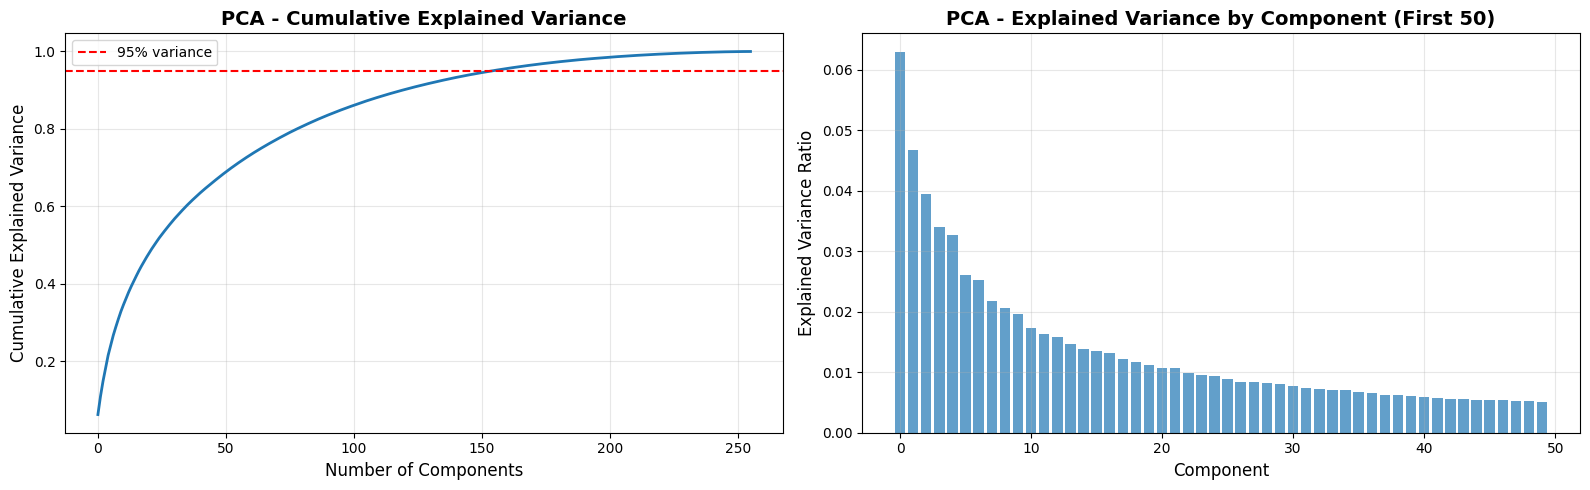

Saved to output/Experiments/LatentVectorAnalysis/pca_explained_variance.png

PCA Summary:
Components needed for 95% variance: 156
Components needed for 99% variance: 212


In [13]:
# Standardize latent vectors
scaler = StandardScaler()
val_latent_scaled = scaler.fit_transform(val_latent_array)
test_latent_scaled = scaler.transform(test_latent_array)

# Apply PCA
pca = PCA()
val_pca = pca.fit_transform(val_latent_scaled)
test_pca = pca.transform(test_latent_scaled)

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(cumsum_var, linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[0].set_xlabel('Number of Components', fontsize=12)
axes[0].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[0].set_title('PCA - Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Individual explained variance
axes[1].bar(range(min(50, len(pca.explained_variance_ratio_))), 
             pca.explained_variance_ratio_[:50], alpha=0.7)
axes[1].set_xlabel('Component', fontsize=12)
axes[1].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[1].set_title('PCA - Explained Variance by Component (First 50)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(latent_output_dir, 'pca_explained_variance.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {os.path.join(latent_output_dir, 'pca_explained_variance.png')}")
print(f"\nPCA Summary:")
print(f"Components needed for 95% variance: {np.argmax(cumsum_var >= 0.95) + 1}")
print(f"Components needed for 99% variance: {np.argmax(cumsum_var >= 0.99) + 1}")

## 2D Visualization using PCA

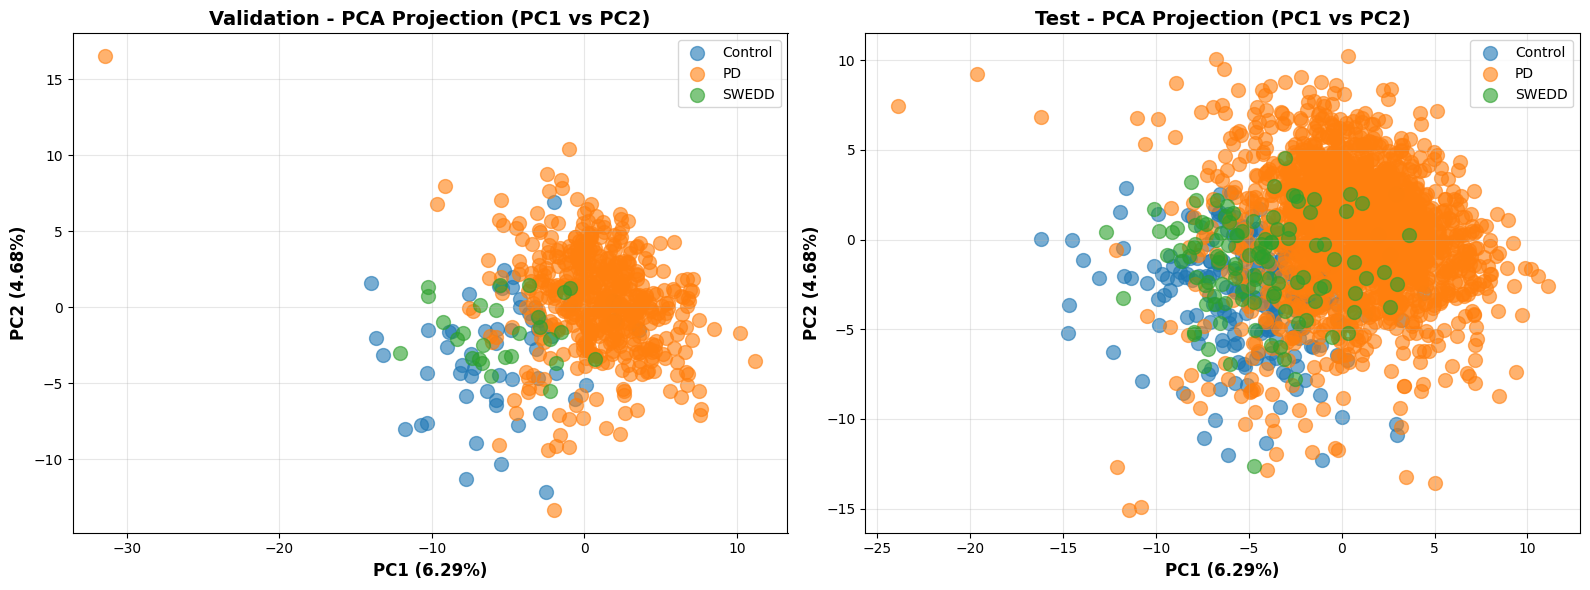

Saved to output/Experiments/LatentVectorAnalysis/pca_2d_projection.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Validation
for label in sorted(set(val_labels)):
    mask = np.array(val_labels) == label
    axes[0].scatter(val_pca[mask, 0], val_pca[mask, 1], label=label, s=100, alpha=0.6)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12, fontweight='bold')
axes[0].set_title('Validation - PCA Projection (PC1 vs PC2)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
for label in sorted(set(test_labels)):
    mask = np.array(test_labels) == label
    axes[1].scatter(test_pca[mask, 0], test_pca[mask, 1], label=label, s=100, alpha=0.6)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12, fontweight='bold')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12, fontweight='bold')
axes[1].set_title('Test - PCA Projection (PC1 vs PC2)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(latent_output_dir, 'pca_2d_projection.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {os.path.join(latent_output_dir, 'pca_2d_projection.png')}")

## Distribution Histograms

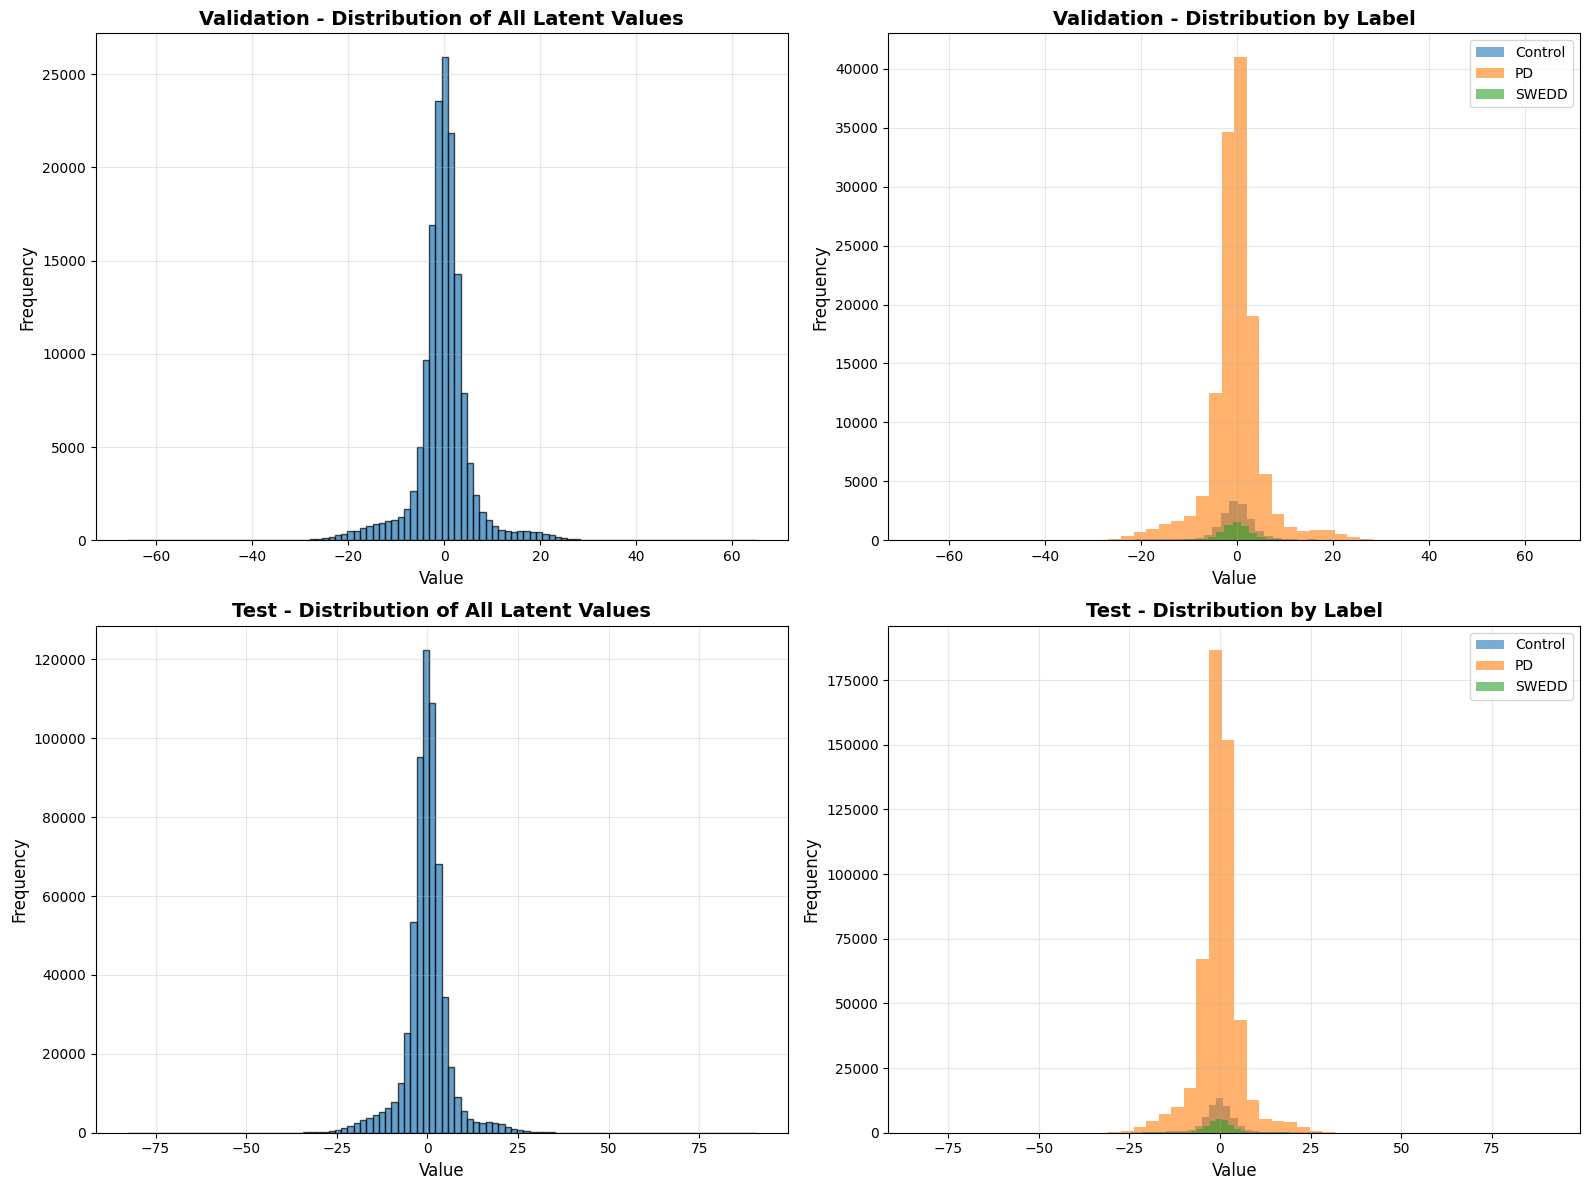

Saved to output/Experiments/LatentVectorAnalysis/latent_distributions.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Validation - all dimensions
axes[0, 0].hist(val_latent_array.flatten(), bins=100, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Validation - Distribution of All Latent Values', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Value', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Validation - by label
for label in sorted(set(val_labels)):
    mask = np.array(val_labels) == label
    axes[0, 1].hist(val_latent_array[mask].flatten(), bins=50, alpha=0.6, label=label)

axes[0, 1].set_title('Validation - Distribution by Label', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Value', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Test - all dimensions
axes[1, 0].hist(test_latent_array.flatten(), bins=100, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Test - Distribution of All Latent Values', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Value', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Test - by label
for label in sorted(set(test_labels)):
    mask = np.array(test_labels) == label
    axes[1, 1].hist(test_latent_array[mask].flatten(), bins=50, alpha=0.6, label=label)

axes[1, 1].set_title('Test - Distribution by Label', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Value', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(latent_output_dir, 'latent_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {os.path.join(latent_output_dir, 'latent_distributions.png')}")